

## Analysis of Aroma Compound Differences Between OLD and NEW Potatoes

This notebook investigates the differences in aroma compound profiles between freshly harvested (NEW) and stored (OLD) potato samples. The goal is to identify how storage affects chemical composition and to determine which compounds and varieties are most influenced by aging.

The analysis includes:

- **Data preprocessing and alignment** of shared compounds and varieties
- **Differential analysis** using statistical testing (Wilcoxon test) and fold-change metrics to identify significantly changing compounds
- **Principal Component Analysis (PCA)** to explore overall variation and separation between NEW and OLD samples
- **Trajectory analysis** to evaluate how individual varieties shift in chemical space during storage
- **Loadings analysis** to identify key compounds driving variation in PCA
- **Clustering (GMM)** to detect subgroups and heterogeneity within each age group
- **Variety-level stability analysis** to identify varieties that are more stable or more sensitive to aging

Overall, this notebook provides a structured comparison of chemical profiles, highlighting both global patterns and specific compound-level changes associated with storage.



In [0]:
import pandas as pd
import numpy as np
import glob, os
import yaml
import os
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from sklearn.mixture import GaussianMixture

In [0]:


CONFIG_PATH = "/Volumes/bmqg/default_bronze/fatemeh/config_mixed.yaml"

with open(CONFIG_PATH, "r") as f:
     CONFIG = yaml.safe_load(f)

# Comparing the compound of newharvested potato compound with old potato

In [0]:


old_path = CONFIG["paths"]["aroma_matrix"]
new_path = CONFIG["paths"]["aroma_matrix_newharvested"]

assert os.path.exists(old_path), f"Old aroma matrix not found: {old_path}"
assert os.path.exists(new_path), f"New aroma matrix not found: {new_path}"

print("Old file:", old_path)
print("New file:", new_path)

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
old_df = pd.read_csv(old_path)
new_df = pd.read_csv(new_path)

assert "Variety" in old_df.columns, "Old file must contain a 'Variety' column"
assert "Variety" in new_df.columns, "New file must contain a 'Variety' column"

# ------------------------------------------------------------
# Clean Variety names
# ------------------------------------------------------------
old_df["Variety"] = old_df["Variety"].astype(str).str.strip().str.upper()
new_df["Variety"] = new_df["Variety"].astype(str).str.strip().str.upper()

# ------------------------------------------------------------
# Collapse duplicates if present
# ------------------------------------------------------------
old_df = old_df.groupby("Variety", as_index=False).mean(numeric_only=True)
new_df = new_df.groupby("Variety", as_index=False).mean(numeric_only=True)

# ------------------------------------------------------------
# Identify compound columns
# ------------------------------------------------------------
old_compounds = [c for c in old_df.columns if c != "Variety"]
new_compounds = [c for c in new_df.columns if c != "Variety"]

old_set = set(old_compounds)
new_set = set(new_compounds)

only_old = sorted(old_set - new_set)
only_new = sorted(new_set - old_set)
shared_compounds = sorted(old_set & new_set)

print("\n===== BASIC SUMMARY =====")
print("Old shape:", old_df.shape)
print("New shape:", new_df.shape)
print("Old compounds:", len(old_compounds))
print("New compounds:", len(new_compounds))
print("Shared compounds:", len(shared_compounds))
print("Only in old:", len(only_old))
print("Only in new:", len(only_new))

print("\n===== COMPOUNDS ONLY IN OLD =====")
for c in only_old:
    print("-", c)

print("\n===== COMPOUNDS ONLY IN NEW =====")
for c in only_new:
    print("-", c)

# ------------------------------------------------------------
# Compare varieties
# ------------------------------------------------------------
old_varieties = set(old_df["Variety"])
new_varieties = set(new_df["Variety"])
shared_varieties = sorted(old_varieties & new_varieties)

print("\n===== VARIETY SUMMARY =====")
print("Old varieties:", len(old_varieties))
print("New varieties:", len(new_varieties))
print("Shared varieties:", len(shared_varieties))
print("Only in old varieties:", sorted(old_varieties - new_varieties)[:20])
print("Only in new varieties:", sorted(new_varieties - old_varieties)[:20])

# ------------------------------------------------------------
# Align on shared varieties + shared compounds
# ------------------------------------------------------------
old_aligned = (
    old_df[old_df["Variety"].isin(shared_varieties)]
    .set_index("Variety")
    .loc[shared_varieties, shared_compounds]
    .copy()
)

new_aligned = (
    new_df[new_df["Variety"].isin(shared_varieties)]
    .set_index("Variety")
    .loc[shared_varieties, shared_compounds]
    .copy()
)

# ------------------------------------------------------------
# Compare shared compounds
# ------------------------------------------------------------
eps = 1e-9

summary = pd.DataFrame({
    "compound": shared_compounds,
    "old_mean": [old_aligned[c].mean() for c in shared_compounds],
    "new_mean": [new_aligned[c].mean() for c in shared_compounds],
})

summary["difference_new_minus_old"] = summary["new_mean"] - summary["old_mean"]
summary["fold_change_new_over_old"] = (summary["new_mean"] + eps) / (summary["old_mean"] + eps)
summary["log2FC_new_over_old"] = np.log2(summary["fold_change_new_over_old"])
summary["fraction_varieties_new_gt_old"] = [
    (new_aligned[c] > old_aligned[c]).mean() for c in shared_compounds
]

# ------------------------------------------------------------
# Save outputs next to the newharvested output folder
# ------------------------------------------------------------
out_dir = os.path.dirname(new_path)

only_old_df = pd.DataFrame({"compound_only_in_old": only_old})
only_new_df = pd.DataFrame({"compound_only_in_new": only_new})

only_old_out = os.path.join(out_dir, "compounds_only_in_old.csv")
only_new_out = os.path.join(out_dir, "compounds_only_in_new.csv")
summary_out = os.path.join(out_dir, "shared_compounds_comparison_old_vs_new.csv")

only_old_df.to_csv(only_old_out, index=False)
only_new_df.to_csv(only_new_out, index=False)
summary.to_csv(summary_out, index=False)

print("\n===== SAVED FILES =====")
print(only_old_out)
print(only_new_out)
print(summary_out)

Old file: /Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs/aroma_matrix_GWAS_clean.csv
New file: /Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_newharvested/matched_per_variety_STRICT_ONLY.csv

===== BASIC SUMMARY =====
Old shape: (94, 68)
New shape: (95, 39)
Old compounds: 67
New compounds: 38
Shared compounds: 31
Only in old: 36
Only in new: 7

===== COMPOUNDS ONLY IN OLD =====
- (E)-2-Heptenal
- (E, E)-2,4-Decadienal
- (E, E)-3,5-Octadien-2-one
- 1-Heptanol
- 1-Nonanol
- 1-Phenylethanol
- 2(3H)-Furanone, dihydro-5-pentyl-
- 2-Decanone
- 2-Heptanone
- 2-Methylbutanal
- 2-Nonanone
- 2-Nonenal, (E)-
- 2-Octenal, (E)-
- 2-Tridecenal
- 3-Furaldehyde
- 3-Heptanone
- Benzoic acid, methyl ester
- Dimethyl sulfide
- Dodecanal
- Ethanol
- Ethanol, 2-phenoxy-
- Ethyl butanoate
- Furfural
- Heptanal
- Methional
- Methyl 8-oxooctanoate
- Nonanoic acid, 9-oxo-, methyl ester
- Octanoic acid, methyl ester
- Phenylacetaldehyde
- Propanal
- Styrene
- Tridecanal
- Undecan

# Top higher and lower compounds in new potato

In [0]:
# Top 20 compounds with highest increase in new
top_higher = summary.sort_values("log2FC_new_over_old", ascending=False).head(20)
print("Top HIGHER in NEW:")
display(top_higher[[
    "compound",
    "old_mean",
    "new_mean",
    "difference_new_minus_old",
    "fold_change_new_over_old",
    "log2FC_new_over_old",
    "fraction_varieties_new_gt_old"
]])

# Top 20 compounds with strongest decrease in new
top_lower = summary.sort_values("log2FC_new_over_old", ascending=True).head(20)
print("Top LOWER in NEW:")
display(top_lower[[
    "compound",
    "old_mean",
    "new_mean",
    "difference_new_minus_old",
    "fold_change_new_over_old",
    "log2FC_new_over_old",
    "fraction_varieties_new_gt_old"
]])

Top HIGHER in NEW:


compound,old_mean,new_mean,difference_new_minus_old,fold_change_new_over_old,log2FC_new_over_old,fraction_varieties_new_gt_old
(E)-2-Decenal,134566.80876472298,1759099.0319148935,1624532.2231501706,13.072309940785589,3.7084421897820508,1.0
1-Octyn-3-ol,269549.6648063498,1759099.0319148935,1489549.3671085439,6.526066478986951,2.706213683785324,1.0
"Acetic acid, methyl ester",392709.4266269534,725272.9361702128,332563.5095432594,1.8468437144473508,0.8850617862274538,0.851063829787234
2-Ethylfuran,208861.9812040625,332587.6170212766,123725.63581721412,1.592379882178418,0.6711845499249885,0.574468085106383
"1-Hexanol, 2-ethyl-",1412043.1905833439,1759099.0319148935,347055.8413315497,1.2457827378411659,0.3170524870059988,0.5851063829787234
Hexanoic acid,113522.44251343318,129683.43617021276,16160.993656779581,1.142359460376014,0.19201668756767387,0.5957446808510638
Dimethyl phthalate,782290.6657145174,435287.670212766,-347002.9955017514,0.5564270280729856,-0.8457355953526277,0.2872340425531915
1-Octen-3-ol,87771.65337132204,47240.984042553195,-40530.66932876885,0.5382259787530546,-0.8937160671314972,0.2127659574468085
Benzyl alcohol,305427.01490204164,159080.75531914894,-146346.2595828927,0.5208470356499759,-0.9410683563782958,0.26595744680851063
"Acetic acid, ethenyl ester",2551293.627256339,1299680.414893617,-1251613.212362722,0.5094201627788698,-0.9730720324770328,0.11702127659574468


Top LOWER in NEW:


compound,old_mean,new_mean,difference_new_minus_old,fold_change_new_over_old,log2FC_new_over_old,fraction_varieties_new_gt_old
Nonanal,1.5257865832112374E7,157550.44680851063,-1.5100315385303862E7,0.010325850845858405,-6.597595525754615,0.0
1-Penten-3-one,310917.23216883047,9941.38829787234,-300975.84387095814,0.03197438825930066,-4.966939432347744,0.0
"Furan, 2-pentyl-",991725.4163897273,36087.51063829787,-955637.9057514294,0.03638861124450318,-4.780369197372284,0.0
Decanal,4986206.940778755,284931.4840425532,-4701275.456736201,0.05714393474372185,-4.12925581083658,0.0
Benzoic acid,496672.4167668943,36581.29255319149,-460091.1242137028,0.07365275646133031,-3.763116670505781,0.0
Dimethyl trisulfide,662350.1538869767,85244.22872340426,-577105.9251635724,0.12869964356942112,-2.9579200368325598,0.010638297872340425
Butanoic acid,895398.4842588451,129683.43617021276,-765715.0480886323,0.14483320940347297,-2.7875356530434447,0.02127659574468085
Tetradecane,2764525.437457234,426460.0106382979,-2338065.426818936,0.15426156144562364,-2.696549475754443,0.0
"2-Propanone, 1-methoxy-",9403607.508534227,1456876.2925531915,-7946731.215981035,0.15492738198941278,-2.690335945148791,0.0
6-Methyl-5-hepten-2-one,407795.5661984003,74645.39893617021,-333150.16726223007,0.18304612684252342,-2.449720847572142,0.0


# stable compounds across aging

In [0]:
eps = 1e-9

log2fc = np.log2((old_aligned + eps) / (new_aligned + eps))

stable_compounds = pd.DataFrame({
    "compound": log2fc.columns,
    "median_log2FC": log2fc.median(),
    "std_log2FC": log2fc.std()
}).reset_index(drop=True)

# compounds closest to zero change
stable = stable_compounds.sort_values("median_log2FC", key=lambda x: abs(x)).head(20)

display(stable)

compound,median_log2FC,std_log2FC
"1-Hexanol, 2-ethyl-",-0.23195402206534632,1.5349564760449583
Hexanoic acid,-0.2725113007922188,0.9967788829861285
2-Ethylfuran,-0.343075421065553,1.794973391465626
1-Octen-3-ol,0.8243505409916663,1.0156122530258438
Benzyl alcohol,0.8269432188295067,1.4346387371920373
"2,3-Butanedione",0.9738802759757421,0.8049373169964463
"Acetic acid, ethenyl ester",0.9738802759757421,0.8049373169964463
Dimethyl phthalate,1.0233307049042377,1.8910064758110297
"Butanal, 3-methyl-",1.3073401634581439,1.9401020286794726
Benzaldehyde,1.369897230133287,0.8649890520974919


| compound            | log2FC |
| ------------------- | ------ |
| 1-Hexanol, 2-ethyl- | -0.23  |
| Hexanoic acid       | -0.27  |
| 2-Ethylfuran        | -0.34  |

# Direction of Shared Compounds with Aging

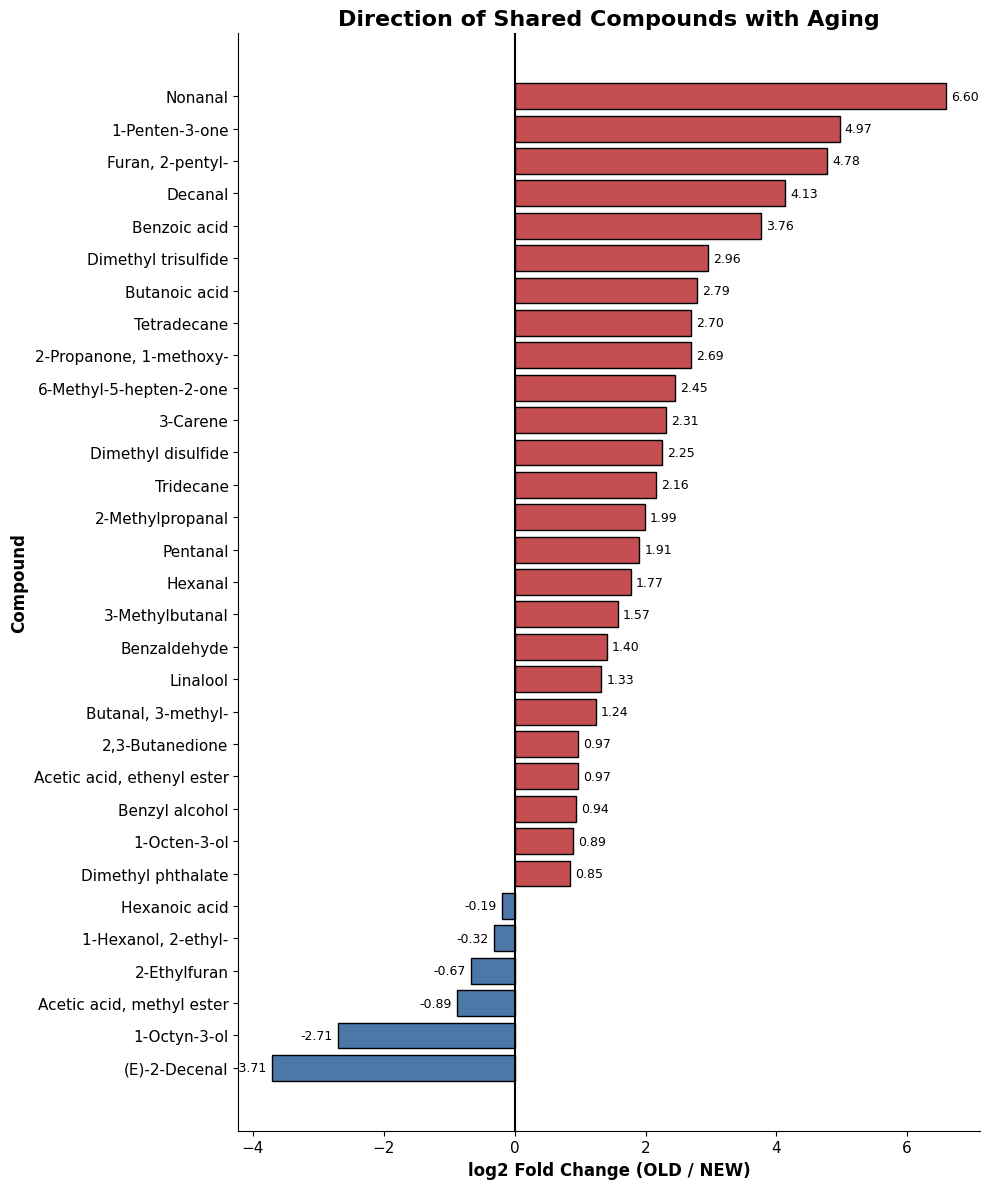

In [0]:

# sort for plotting
plot_df = summary.sort_values("log2FC_old_over_new", ascending=True).copy()

fig, ax = plt.subplots(figsize=(10, 12))

colors = np.where(
    plot_df["log2FC_old_over_new"] > 0,
    "#c44e52",   # OLD > NEW
    "#4c78a8"    # NEW > OLD
)

bars = ax.barh(
    plot_df["compound"],
    plot_df["log2FC_old_over_new"],
    color=colors,
    edgecolor="black",
    linewidth=1
)

# zero line
ax.axvline(0, color="black", linewidth=1.5)

# labels and title
ax.set_title("Direction of Shared Compounds with Aging", fontsize=16, fontweight="bold")
ax.set_xlabel("log2 Fold Change (OLD / NEW)", fontsize=12, fontweight="bold")
ax.set_ylabel("Compound", fontsize=12, fontweight="bold")

# cleaner style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=11)

#  value labels
for bar, value in zip(bars, plot_df["log2FC_old_over_new"]):
    y = bar.get_y() + bar.get_height() / 2
    if value > 0:
        ax.text(value + 0.08, y, f"{value:.2f}", va="center", ha="left", fontsize=9)
    else:
        ax.text(value - 0.08, y, f"{value:.2f}", va="center", ha="right", fontsize=9)

plt.tight_layout()
plt.show()

#  Multivariate Analysis of Aroma Profiles: PCA, Differential Patterns, and Variety-Level Aging Effects

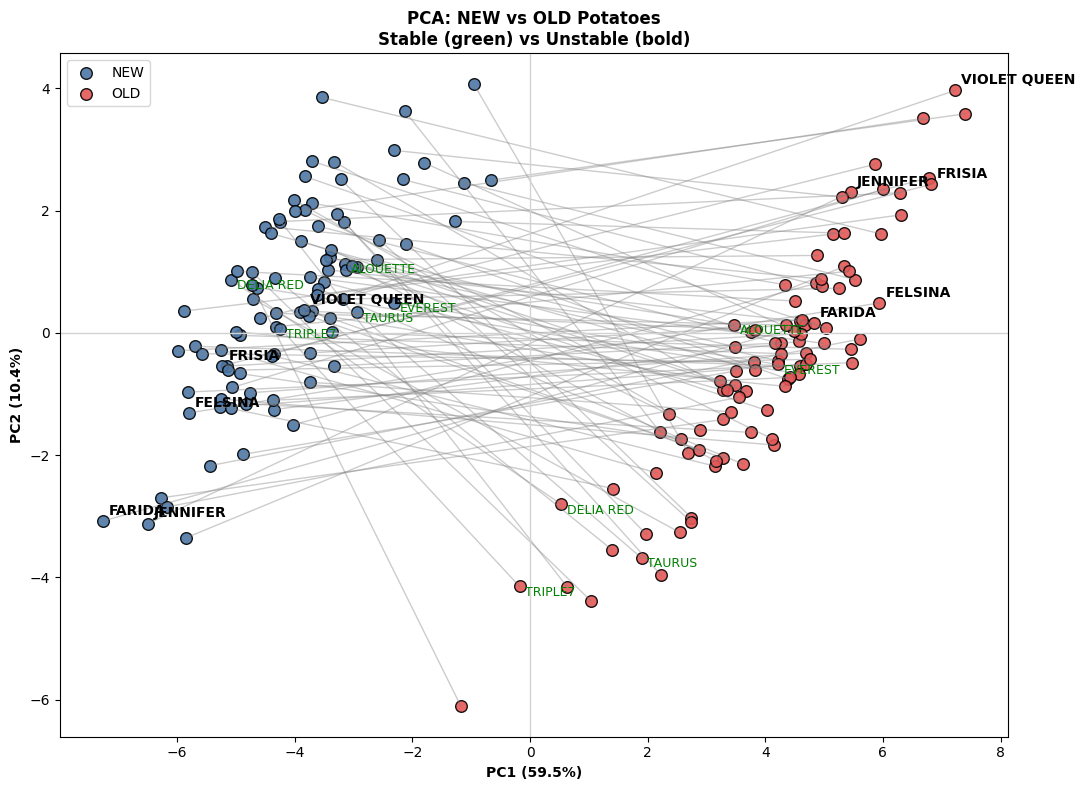

Saved PCA plot: /Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_newharvested/pca_stable_vs_unstable.png


In [0]:
# ============================================================
# PCA + STABLE vs UNSTABLE VARIETY VISUALIZATION
# ============================================================

# --- Combine data ---
combined = pd.concat([
    new_aligned.assign(Variety=new_aligned.index, Age="NEW"),
    old_aligned.assign(Variety=old_aligned.index, Age="OLD")
], ignore_index=True)

# ============================================================
# PCA
# ============================================================
X = np.log1p(combined[shared_compounds])
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)

combined[["PC1", "PC2"]] = pcs
pc_var = pca.explained_variance_ratio_ * 100

# ============================================================
# Compute variety shift (aging effect)
# ============================================================
log2fc = np.log2((old_aligned + eps) / (new_aligned + eps))

variety_shift = pd.DataFrame({
    "euclidean_shift": np.sqrt(
        ((np.log1p(old_aligned) - np.log1p(new_aligned)) ** 2).sum(axis=1)
    ),
    "mean_abs_log2FC": log2fc.abs().mean(axis=1)
}).sort_values("euclidean_shift", ascending=False)

# --- Select top unstable and stable varieties ---
top_varieties = variety_shift.head(5).index       # most changed
stable_varieties = variety_shift.tail(5).index    # least changed

# ============================================================
# PCA Plot
# ============================================================
plt.figure(figsize=(11, 8))

colors = {"NEW": "#4C78A8", "OLD": "#E45756"}

# --- draw trajectories ---
for v in shared_varieties:
    sub = combined[combined["Variety"] == v]
    if len(sub) == 2:
        sub = sub.sort_values("Age")
        plt.plot(
            sub["PC1"],
            sub["PC2"],
            color="gray",
            alpha=0.4,
            linewidth=1
        )

# --- scatter points ---
for age in ["NEW", "OLD"]:
    sub = combined[combined["Age"] == age]
    plt.scatter(
        sub["PC1"],
        sub["PC2"],
        c=colors[age],
        label=age,
        edgecolor="black",
        s=70,
        alpha=0.9
    )

# ============================================================
# Label UNSTABLE varieties (high change)
# ============================================================
for _, row in combined.iterrows():
    if row["Variety"] in top_varieties:
        plt.text(
            row["PC1"] + 0.1,
            row["PC2"] + 0.1,
            row["Variety"],
            fontsize=10,
            fontweight="bold",
            color="black"
        )

# ============================================================
# Label STABLE varieties (low change)
# ============================================================
for _, row in combined.iterrows():
    if row["Variety"] in stable_varieties:
        plt.text(
            row["PC1"] + 0.1,
            row["PC2"] - 0.15,
            row["Variety"],
            fontsize=9,
            color="green"
        )

# ============================================================
# Styling
# ============================================================
plt.xlabel(f"PC1 ({pc_var[0]:.1f}%)", fontweight="bold")
plt.ylabel(f"PC2 ({pc_var[1]:.1f}%)", fontweight="bold")
plt.title("PCA: NEW vs OLD Potatoes\nStable (green) vs Unstable (bold)", fontweight="bold")

plt.axhline(0, color="lightgray", linewidth=1)
plt.axvline(0, color="lightgray", linewidth=1)

plt.legend()
plt.tight_layout()

# --- Save ---
pca_plot_path = os.path.join(out_dir, "pca_stable_vs_unstable.png")
plt.savefig(pca_plot_path, dpi=300)
plt.show()

print("Saved PCA plot:", pca_plot_path)

# ============================================================
# Save variety groups (optional but professional)
# ============================================================
pd.DataFrame({"unstable_varieties": top_varieties}).to_csv(
    os.path.join(out_dir, "top_unstable_varieties.csv"), index=False
)

pd.DataFrame({"stable_varieties": stable_varieties}).to_csv(
    os.path.join(out_dir, "stable_varieties.csv"), index=False
)

# Top genotypes with the largest compound-profile changes during aging

In [0]:

eps = 1e-9

# per-variety log2 fold change matrix
log2fc_by_variety = np.log2((old_aligned + eps) / (new_aligned + eps))

# summarize genotype-level aging shift
variety_shift = pd.DataFrame({
    "genotype": log2fc_by_variety.index,
    "euclidean_shift_log_space": np.sqrt((log2fc_by_variety ** 2).sum(axis=1)),
    "mean_abs_log2FC": log2fc_by_variety.abs().mean(axis=1),
    "n_compounds_higher_in_old": (log2fc_by_variety > 0).sum(axis=1),
    "n_compounds_higher_in_new": (log2fc_by_variety < 0).sum(axis=1),
    "fraction_compounds_higher_in_old": (log2fc_by_variety > 0).mean(axis=1)
}).sort_values(
    ["euclidean_shift_log_space", "mean_abs_log2FC"],
    ascending=False
)

display(variety_shift.head(20))

genotype,euclidean_shift_log_space,mean_abs_log2FC,n_compounds_higher_in_old,n_compounds_higher_in_new,fraction_compounds_higher_in_old
FELSINA,21.40896103599003,3.3427970725494753,27,4,0.8709677419354839
FRISIA,21.33746694224906,3.376787442520659,28,3,0.9032258064516129
FARIDA,21.149984597053958,3.3208876567423298,28,3,0.9032258064516129
JENNIFER,21.08850756950256,3.3242586272183146,27,4,0.8709677419354839
VIOLET QUEEN,20.93624757796584,3.2340378191343726,28,3,0.9032258064516129
FENWAY RED,20.81061123464862,3.2513056363550072,27,4,0.8709677419354839
MARILYN,20.77639967178947,3.193238982096799,26,5,0.8387096774193549
CARDYMA,20.68848662034036,3.0008434122072054,25,6,0.8064516129032258
FABULA,20.68455587189599,3.2159345596891717,28,3,0.9032258064516129
VE 71-105,20.404598752226992,3.1516052820860105,26,5,0.8387096774193549


# Compounds Driving the Positive and Negative Sides of PCA Axis 1 (PC1)

In [0]:
# PC1 loadings
pc1_loadings = pd.Series(
    pca.components_[0],
    index=shared_compounds,
    name="PC1_loading"
)

# mean abundance (FIXED)
mean_abundance = combined[shared_compounds].mean()
mean_abundance.name = "mean_abundance"

# driver score
driver_score = pc1_loadings * mean_abundance

drivers = pd.concat(
    [pc1_loadings, mean_abundance, driver_score.rename("driver_score")],
    axis=1
)

drivers["compound"] = drivers.index

# RIGHT side PCA (positive PC1)
drivers_right = drivers.sort_values("driver_score", ascending=False).head(15)

# LEFT side PCA (negative PC1)
drivers_left = drivers.sort_values("driver_score").head(15)

print("Compounds driving RIGHT side of PCA")
display(drivers_right)

print("Compounds driving LEFT side of PCA")
display(drivers_left)

Compounds driving RIGHT side of PCA


PC1_loading,mean_abundance,driver_score,compound
0.22707025392986127,7707708.139460444,1750191.2444445416,Nonanal
0.20051411022927304,5430241.900543708,1088840.1230172382,"2-Propanone, 1-methoxy-"
0.22562792756733063,2635569.212410654,594658.0193564777,Decanal
0.18579798074268639,2218729.61930879,412235.4830815625,3-Methylbutanal
0.1878564484070813,1925487.021074978,361715.1532330763,"2,3-Butanedione"
0.18785644840708132,1925487.021074978,361715.1532330763,"Acetic acid, ethenyl ester"
0.20763786196169376,1595492.724047766,331284.69799671683,Tetradecane
0.2115158700654019,1358438.2216582936,287331.24238415126,Dimethyl disulfide
0.20357177048040712,1333471.6550366073,271457.18570124084,Benzaldehyde
0.18014899164090137,1415708.870583983,255038.52549278384,Hexanal


Compounds driving LEFT side of PCA


PC1_loading,mean_abundance,driver_score,compound
-0.1760860183100643,1014324.3483606217,-178608.33577777247,1-Octyn-3-ol
-0.18776128326001265,946832.9203398083,-177778.56415582774,(E)-2-Decenal
-0.10037346883295444,558991.1813985831,-56107.88392400706,"Acetic acid, methyl ester"
-0.003569117808607425,1585571.1112491188,-5659.090089972695,"1-Hexanol, 2-ethyl-"
-0.00784783032112545,270724.79911266954,-2124.602287157004,2-Ethylfuran
0.008191179013224609,121602.939341823,996.0714446831657,Hexanoic acid
0.14708043084313047,59407.45575758668,8737.67418812006,Linalool
0.15256263058515415,67506.31870693761,10298.941563050204,1-Octen-3-ol
0.09586382794150074,109081.30966185917,10456.95190105803,"Butanal, 3-methyl-"
0.21642719218025575,107387.46562641833,23241.56766087945,3-Carene


# PCA-Based Clustering of Aroma Profiles Using Gaussian Mixture Models (NEW vs OLD Potatoes)

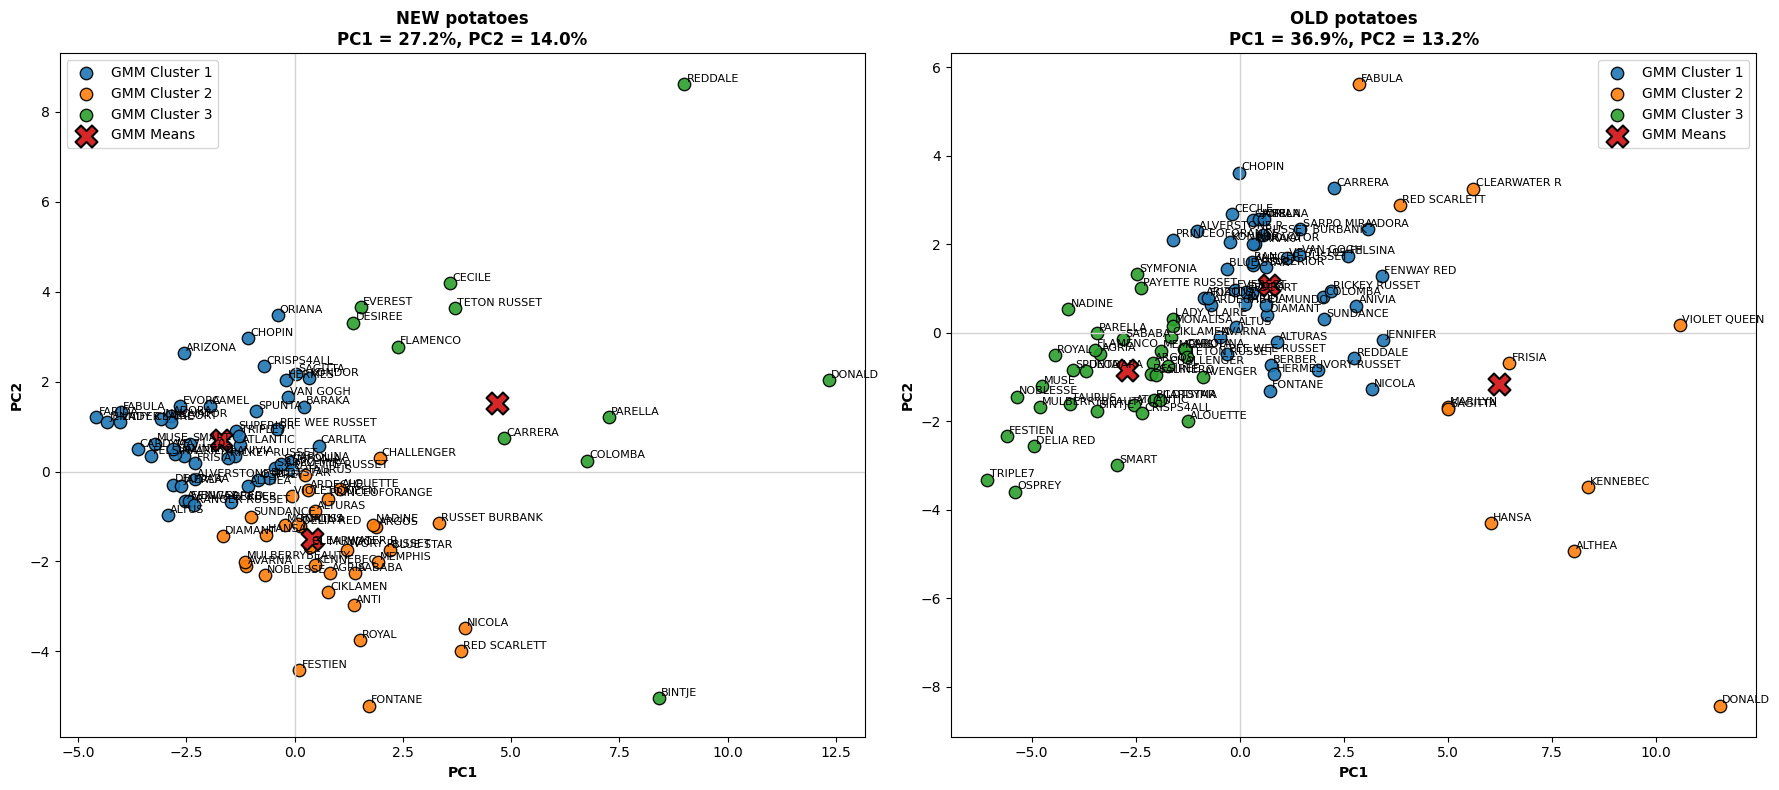

In [0]:


# ------------------------------------------------------------

# Variety, Age, and numeric compound columns
# ------------------------------------------------------------

required_cols = ["Variety", "Age"]
missing = [c for c in required_cols if c not in combined.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# numeric columns = compounds
compound_cols = combined.select_dtypes(include=[np.number]).columns.tolist()

# remove helper/result columns if they exist
exclude_cols = ["PC1", "PC2", "ID", "Batch", "Replicate", "Cluster"]
compound_cols = [c for c in compound_cols if c not in exclude_cols]

if len(compound_cols) < 2:
    raise ValueError("Not enough numeric compound columns for PCA.")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

age_settings = [
    ("NEW", axes[0]),
    ("OLD", axes[1]),
]

for age_group, ax in age_settings:
    sub = combined[combined["Age"].astype(str).str.upper() == age_group].copy()
    sub = sub.dropna(subset=compound_cols).copy()

    if len(sub) < 4:
        ax.set_title(f"{age_group} potatoes\nNot enough data")
        continue

    # -------------------------
    # PCA
    # -------------------------
    X = sub[compound_cols].values
    X_scaled = StandardScaler().fit_transform(X)

    pca = PCA(n_components=2)
    scores = pca.fit_transform(X_scaled)

    sub["PC1"] = scores[:, 0]
    sub["PC2"] = scores[:, 1]

    # -------------------------
    # GMM clustering on PCA scores
    # -------------------------
    n_clusters = 3
    gmm = GaussianMixture(
        n_components=n_clusters,
        covariance_type="full",
        random_state=42
    )
    sub["Cluster"] = gmm.fit_predict(sub[["PC1", "PC2"]])

    # probability of assigned cluster
    probs = gmm.predict_proba(sub[["PC1", "PC2"]])
    sub["MaxProb"] = probs.max(axis=1)

    # plot each cluster
    for cl in sorted(sub["Cluster"].unique()):
        cluster_data = sub[sub["Cluster"] == cl]

        ax.scatter(
            cluster_data["PC1"],
            cluster_data["PC2"],
            s=80,
            alpha=0.9,
            edgecolor="black",
            label=f"GMM Cluster {cl+1}"
        )

        for _, row in cluster_data.iterrows():
            ax.text(
                row["PC1"] + 0.05,
                row["PC2"] + 0.05,
                str(row["Variety"]),
                fontsize=8
            )

    # cluster means
    means = gmm.means_
    ax.scatter(
        means[:, 0], means[:, 1],
        s=250,
        marker="X",
        edgecolor="black",
        linewidth=1.5,
        label="GMM Means"
    )

    ax.axhline(0, color="lightgray", linewidth=1)
    ax.axvline(0, color="lightgray", linewidth=1)

    evr1 = pca.explained_variance_ratio_[0] * 100
    evr2 = pca.explained_variance_ratio_[1] * 100

    ax.set_title(
        f"{age_group} potatoes\nPC1 = {evr1:.1f}%, PC2 = {evr2:.1f}%",
        fontweight="bold"
    )
    ax.set_xlabel("PC1", fontweight="bold")
    ax.set_ylabel("PC2", fontweight="bold")
    ax.legend()

plt.tight_layout()
plt.show()

## Comparison of PCA Loadings: Aroma Compound Contributions in NEW vs OLD Potatoes

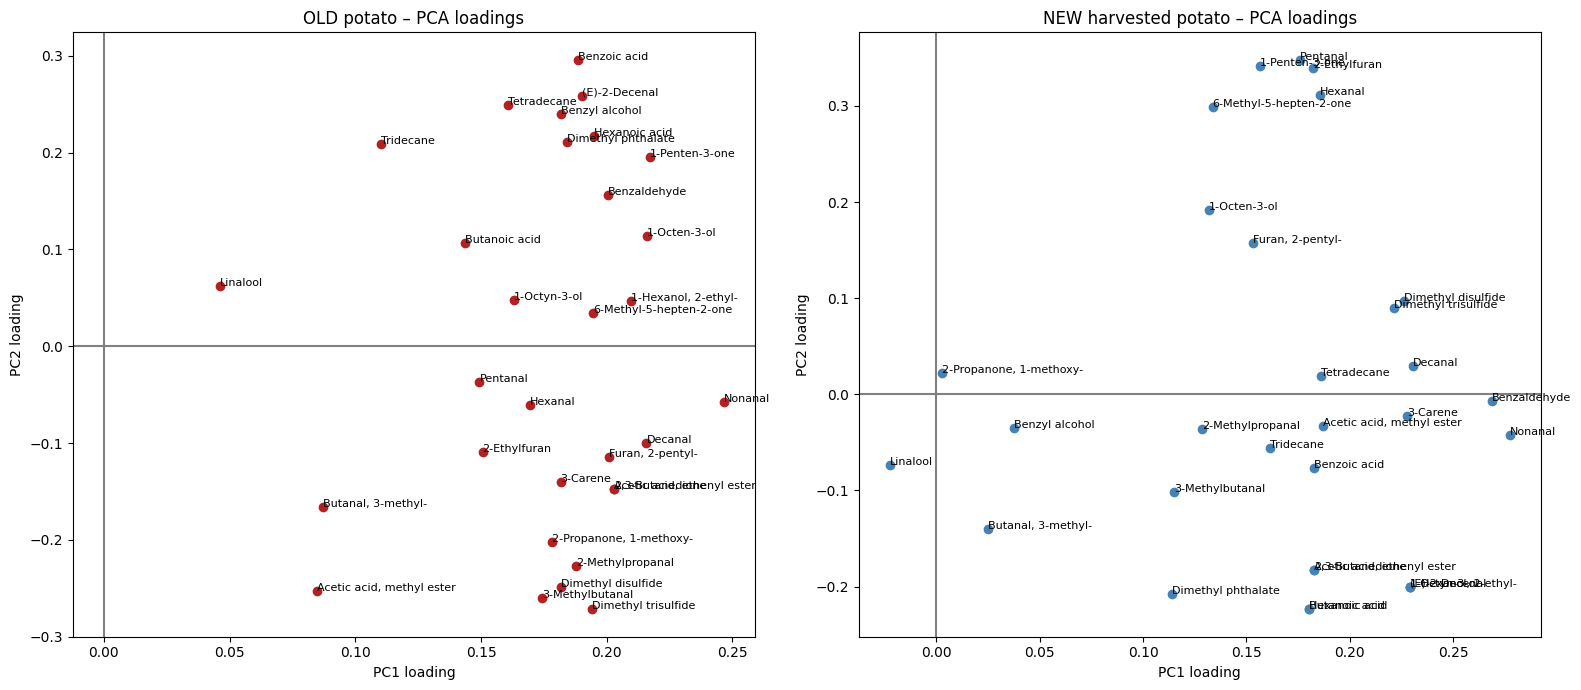

In [0]:
# log transform
X_old_log = np.log1p(old_aligned)
X_new_log = np.log1p(new_aligned)

# scale
scaler_old = StandardScaler()
scaler_new = StandardScaler()

X_old_scaled = scaler_old.fit_transform(X_old_log)
X_new_scaled = scaler_new.fit_transform(X_new_log)

# PCA
pca_old = PCA(n_components=2, random_state=42)
pca_new = PCA(n_components=2, random_state=42)

pca_old.fit(X_old_scaled)
pca_new.fit(X_new_scaled)

loadings_old = pd.DataFrame(
    pca_old.components_.T,
    index=shared_compounds,
    columns=["PC1","PC2"]
)

loadings_new = pd.DataFrame(
    pca_new.components_.T,
    index=shared_compounds,
    columns=["PC1","PC2"]
)
fig, axes = plt.subplots(1,2, figsize=(16,7))

# -------- OLD --------
ax = axes[0]

ax.scatter(loadings_old["PC1"], loadings_old["PC2"], color="firebrick")

for comp in loadings_old.index:
    ax.text(
        loadings_old.loc[comp,"PC1"],
        loadings_old.loc[comp,"PC2"],
        comp,
        fontsize=8
    )

ax.axhline(0,color="grey")
ax.axvline(0,color="grey")

ax.set_title("OLD potato – PCA loadings")
ax.set_xlabel("PC1 loading")
ax.set_ylabel("PC2 loading")


# -------- NEW --------
ax = axes[1]

ax.scatter(loadings_new["PC1"], loadings_new["PC2"], color="steelblue")

for comp in loadings_new.index:
    ax.text(
        loadings_new.loc[comp,"PC1"],
        loadings_new.loc[comp,"PC2"],
        comp,
        fontsize=8
    )

ax.axhline(0,color="grey")
ax.axvline(0,color="grey")

ax.set_title("NEW harvested potato – PCA loadings")
ax.set_xlabel("PC1 loading")
ax.set_ylabel("PC2 loading")

plt.tight_layout()
plt.show()

In old potatoes, several aldehydes and sulfur-containing compounds such as nonanal, decanal, dimethyl disulfide, and dimethyl trisulfide show strong loadings, suggesting that lipid oxidation and amino-acid degradation products play a major role in the aroma profile after storage.

In newly harvested potatoes, compounds such as hexanal, 1-octen-3-ol, pentanal, and 6-methyl-5-hepten-2-one contribute more strongly to the variation, reflecting fresh, green, and lipid-derived volatiles typically associated with recently harvested tubers.

 fresh lipid-derived compounds in new potatoes to oxidation- and sulfur-related compounds in stored potato

# Linear Relationship Between Principal Components

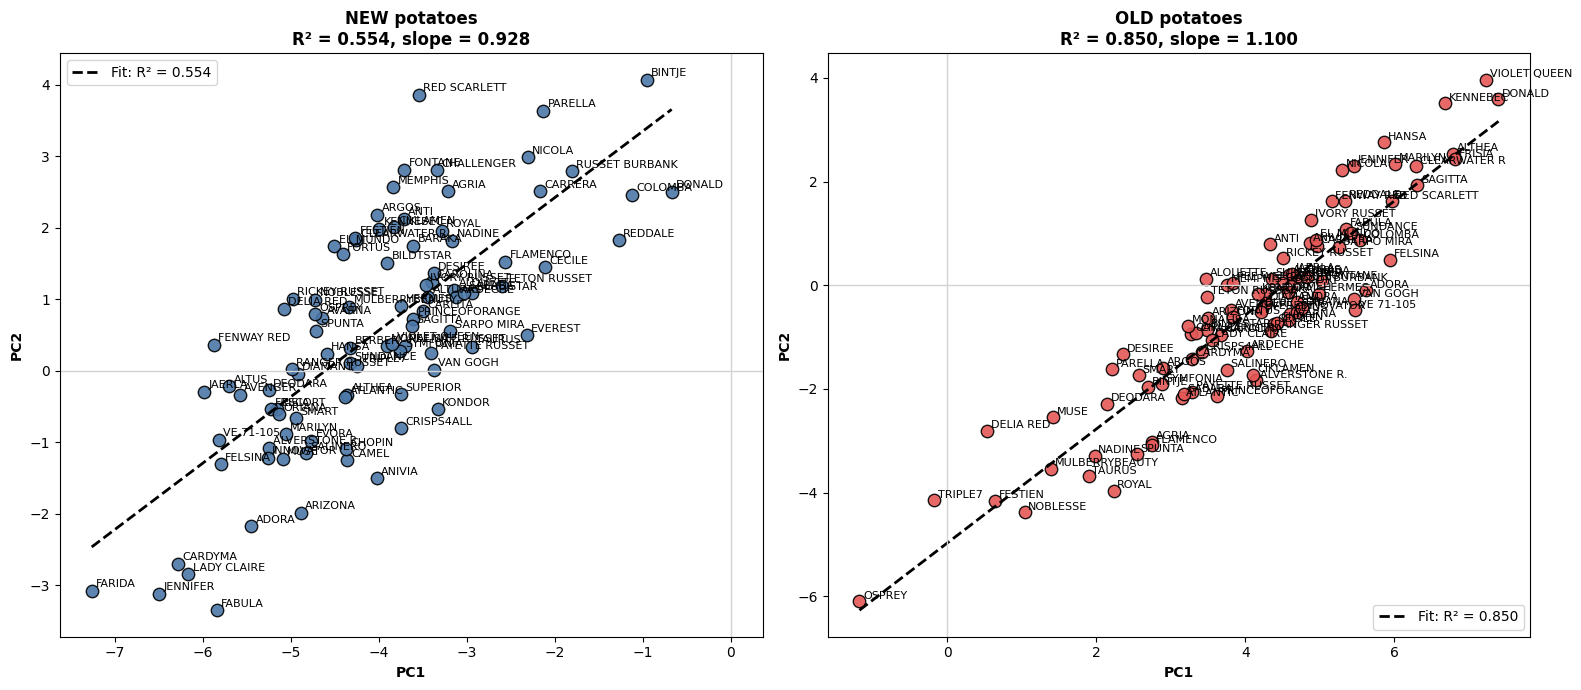

In [0]:


# ------------------------------------------------------------
# Separate linear plots for NEW and OLD with variety names
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=False, sharey=False)

age_settings = [
    ("NEW", "#4C78A8", axes[0]),
    ("OLD", "#E45756", axes[1]),
]

for age_group, color, ax in age_settings:
    sub = combined[combined["Age"] == age_group].copy()

    X = sub[["PC1"]].values
    y = sub["PC2"].values

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)

    # scatter
    ax.scatter(
        sub["PC1"],
        sub["PC2"],
        s=80,
        color=color,
        edgecolor="black",
        alpha=0.9
    )

    # regression line
    x_line = np.linspace(sub["PC1"].min(), sub["PC1"].max(), 200).reshape(-1, 1)
    y_line = model.predict(x_line)

    ax.plot(
        x_line,
        y_line,
        linestyle="--",
        linewidth=2,
        color="black",
        label=f"Fit: R² = {r2:.3f}"
    )

    # annotate variety names
    for _, row in sub.iterrows():
        ax.text(
            row["PC1"] + 0.05,
            row["PC2"] + 0.05,
            row["Variety"],
            fontsize=8
        )

    ax.axhline(0, color="lightgray", linewidth=1)
    ax.axvline(0, color="lightgray", linewidth=1)
    ax.set_title(
        f"{age_group} potatoes\nR² = {r2:.3f}, slope = {model.coef_[0]:.3f}",
        fontweight="bold"
    )
    ax.set_xlabel("PC1", fontweight="bold")
    ax.set_ylabel("PC2", fontweight="bold")
    ax.legend()

plt.tight_layout()
plt.show()